### Default simulation parameters for the Glasma and the Wong solvers

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 10.0
N = 512
tau_sim = 1.0
DTS = 8

# Glasma fields
su_group = 'su3'
uv = 10.0
ir = 0.2
g2mu = 2.0

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_sim / a * DTS)
nplus = maxt//DTS

g = 2         		
mu = g2mu / g**2

ns = 1      

nevents = 5
mode = 'jet'       # 'hq' or 'jet'
inf_solver = 'wong'  # 'wong' or 'qhat' — only used for quark == 'inf' in jet mode

# Condition 1: 2*pi/L < m  (m ir regulator)
cond1_lhs = 2 * np.pi / L * hbarc
cond1 = cond1_lhs < ir
print(f"2π/L = {cond1_lhs:.4f} < m = {ir} {'passed' if cond1 else 'failed'}")

# Condition 2: m / g2mu < 1  (dense glasma)
cond2_lhs = ir / g2mu
cond2 = cond2_lhs < 1
print(f"m/g2mu = {cond2_lhs:.4f} < 1 {'passed' if cond2 else 'failed'}")

# Condition 3: g2mu * a < 1  (fine lattice)
cond3_lhs = g2mu * a / hbarc
cond3 = cond3_lhs < 1
print(f"g2mua = {cond3_lhs:.4f} < 1 {'passed' if cond3 else 'failed'}")

print(f"g2muL = {g2mu * L / hbarc :.4f}")

2π/L = 0.1240 < m = 0.2 passed
m/g2mu = 0.1000 < 1 passed
g2mua = 0.1980 < 1 passed
g2muL = 101.3551


In [2]:
# Wong solver 
mass = 1   
tau_form = 0   
pT = 0   
ntp = 10**5  
# nevents = 10
# nevents = 2    
boundary = 'periodic'       

# Store relevant parameters in a dictionary
p = {
    'QUARK': 'any',
    'MASS': mass, 
    'TFORM': tau_form,
    'TSIM': tau_sim,
    # 'QS': Qs,
    'G2MU': g2mu,            
    'NEVENTS': nevents,
    'NTP': ntp,   
    'PT': pT,
    }

### Set environment variables

In [3]:
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('../..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

import curraun.su as su
from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Wong modules
from curraun import wong
wong.BOUNDARY = boundary
wong.CUB_MOM = False
from curraun.wong import init_mom_toy, init_pos

# qhat module for light-like jets
import curraun.qhat as qhat

Using CUDA
Using SU(3)
Using double precision
Using double precision


#### Initialization of color charge

In [4]:
from scipy.stats import unitary_group

# gell-mann matrices

gm = [
    [[0, 1, 0], [1, 0, 0], [0, 0, 0]],
    [[0, -1j, 0], [1j, 0, 0], [0, 0, 0]],
    [[1, 0, 0], [0, -1, 0], [0, 0, 0]],
    [[0, 0, 1], [0, 0, 0], [1, 0, 0]],
    [[0, 0, -1j], [0, 0, 0], [1j, 0, 0]],
    [[0, 0, 0], [0, 0, 1], [0, 1, 0]],
    [[0, 0, 0], [0, 0, -1j], [0, 1j, 0]],
    [[1 / np.sqrt(3), 0, 0], [0, 1 / np.sqrt(3), 0], [0, 0, -2 / np.sqrt(3)]]
]

T = np.array(gm) / 2.0

def init_charge(q2):
    """
        Step 1: specific random color vector
    """
    # Here q_3=0
    q0 = [np.sqrt(q2), 0., 0., 0., 0., 0., 0., 0.]
    Q0 = np.einsum('ijk,i', T, q0)

    """
        Step 2: create a random SU(3) matrix to rotate Q.
    """
    
    V = unitary_group.rvs(3)
    detV = np.linalg.det(V)
    U = V / detV ** (1 / 3)
    Ud = np.conj(U).T

    Q = np.einsum('ab,bc,cd', U, Q0, Ud)

    """
        Step 3: Project onto color components
    """

    q = 2 * np.einsum('ijk,kj', T, Q)
    return np.real(q)

- - - 
# Dependence of momentum broadening on the quadratic Casimir

In [5]:
import pickle
from tqdm import tqdm

# Simulation routine
def simulate(p, ev):
    q2 = p["q2"]
    quark = p.get("QUARK", "any")

    output = {}
    output["parameters"] = p.copy()

    tau_form = p["TFORM"]
    tau_sim = p["TSIM"] + tau_form
    mass = p["MASS"]
    pT = p.get("PT", 0)
    px = p.get("PX", 0)

    # Derived parameters
    a = L / N
    E0 = N / L * hbarc
    DT = 1.0 / DTS
    formt = int(tau_form / a * DTS)
    maxt = int(tau_sim / a * DTS)

    # Initialize Glasma fields
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the Wong solver
    wong_solver = wong.WongSolver(s, ntp)
    x0s, p0s, q0s = np.zeros((ntp, 3)), np.zeros((ntp, 5)), np.zeros((ntp, su.ALGEBRA_ELEMENTS))
    masses = mass / E0 * np.ones(ntp)

    for i in range(ntp):
        if "PX" in p:
            x0, p0, q0 = init_pos(s.n), init_mom_toy('px', px / E0), init_charge(q2)
        else:
            x0, p0, q0 = init_pos(s.n), init_mom_toy('pT', pT / E0), init_charge(q2)
        x0s[i, :], p0s[i, :], q0s[i, :] = x0, p0, q0

    wong_solver.initialize(x0s, p0s, q0s, masses)

    psq = np.zeros((maxt - formt, 4))

    with tqdm(total=maxt) as pbar:
        for t in range(maxt):
            # Evolve Glasma fields
            core.evolve_leapfrog(s)

            # Solve Wong's equations
            if t >= formt:
                psq_wong = wong_solver.p_sq_mean
                psq[t - formt, :] = psq_wong * E0**2

                wong_solver.evolve()
                wong_solver.compute_mom_broad()

            pbar.set_description("Event " + str(ev + 1))
            pbar.update(1)

    tau_out = np.linspace(0, tau_sim - tau_form, maxt - formt)

    output["psq"], output["tau"] = psq, tau_out

    return output

In [8]:
# q2s = [4/3, 4.0]
# q2s = np.linspace(0, 6, 19)
q2s = np.linspace(1, 4, 10)

if mode == 'hq':
    quarks = ['infmass', 'beauty', 'charm']
    quark_masses = [10**6, 4.18, 1.27]
    pTs = [2, 2, 2]
elif mode == 'jet':
    # quarks = ['inf', '3g2mu', 'g2mu']
    # pxs = [10**6, 3*g2mu, g2mu]
    quarks = ['g2mu']
    pxs = [g2mu]

psq, tau = {}, {}
for iq, quark in enumerate(quarks):
    print(quarks[iq].capitalize() + " quark")
    p['QUARK'] = quark
    if mode == 'hq':
        p['MASS'], p['PT'] = quark_masses[iq], pTs[iq]
        p.pop('PX', None)
        p['TFORM'] = 1/(2*p["MASS"])*hbarc
        if quark == 'infmass':
            p['TFORM'] = 0.
    elif mode == 'jet':
        p['MASS'] = 1
        p['PX'] = pxs[iq]
        p.pop('PT', None)
        p['TFORM'] = 0.

    psq[quark], tau[quark] = {}, {}

    for q2 in q2s:
        p["q2"] = q2
        print("q2 =", p["q2"])

        psqs = []
        for ev in range(nevents):
            if quark == 'inf' and inf_solver == 'qhat':
                output = simulate_qhat(p, ev)
            else:
                output = simulate(p, ev)
            psqs.append(output["psq"])

        psq[quark][str(q2)] = np.mean(psqs, axis=0)

    tau[quark] = output["tau"]

    quark_output = {
        "psq": psq[quark],
        "tau": tau[quark],
        "quark": quark,
        "q2s": q2s,
        "parameters": p.copy(),
    }
    if mode == 'hq':
        quark_output["mass"] = quark_masses[iq]
        quark_output["pT"] = pTs[iq]
        filename = f'hq_mom_broad_q2_dep_g2mu_2_{quark}_N_{N}.pickle'
    elif mode == 'jet':
        quark_output["mass"] = 1
        quark_output["px"] = pxs[iq]
        filename = f'jet_mom_broad_q2_dep_g2mu_2_{quark}_N_{N}.pickle'
    with open(filename, 'wb') as handle:
        pickle.dump(quark_output, handle)
    print(f"Saved {filename}")

G2mu quark
q2 = 1.0


Event 5: 100%|██████████| 409/409 [02:21<00:00,  2.88it/s]


q2 = 1.3333333333333333


Event 5: 100%|██████████| 409/409 [01:52<00:00,  3.64it/s]


q2 = 1.6666666666666665


...

q2 = 3.6666666666666665


Event 5: 100%|██████████| 409/409 [02:00<00:00,  3.38it/s]


q2 = 4.0


Event 5: 100%|██████████| 409/409 [01:57<00:00,  3.49it/s]

Saved jet_mom_broad_q2_dep_g2mu_2_g2mu_N_512.pickle


- - -

In [6]:
import pickle

if mode == 'hq':
    filename_base = 'hq_mom_broad_q2_dep_g2mu_2'
    quarks = ['infmass', 'beauty', 'charm']
elif mode == 'jet':
    filename_base = 'jet_mom_broad_q2_dep_g2mu_2'
    quarks = ['inf', '3g2mu', 'g2mu']

results = {"psq": {}, "tau": {}, "quarks": quarks, "masses": [], "pTs": [], "pxs": []}
for quark in quarks:
    fname = f'{filename_base}_{quark}_N_{N}.pickle'
    with open(fname, 'rb') as handle:
        data = pickle.load(handle)
    results["psq"][quark] = data["psq"]
    results["tau"][quark] = data["tau"]
    results["masses"].append(data["mass"])
    if mode == 'hq':
        results["pTs"].append(data["pT"])
    elif mode == 'jet':
        results["pxs"].append(data["px"])

results["q2s"] = data["q2s"]
results["parameters"] = data["parameters"]
g2mu = 2

if mode == 'hq':
    quarks_cs_list = ['infmass', 'beauty', 'charm']
elif mode == 'jet':
    quarks_cs_list = ['inf', '3g2mu', 'g2mu']

results_cs = {"psq": {}, "tau": {}, "quarks": quarks_cs_list}
for quark in quarks_cs_list:
    if mode == 'hq':
        fname = f'hq_mom_broad_casimir_scaling_{quark}_N_{N}.pickle'
    elif mode == 'jet':
        fname = f'jet_mom_broad_casimir_scaling_{quark}_N_{N}.pickle'
    with open(fname, 'rb') as handle:
        data_cs = pickle.load(handle)
    results_cs["psq"][quark] = data_cs["psq"]
    results_cs["tau"][quark] = data_cs["tau"]

results_cs["q2s"] = data_cs["q2s"]

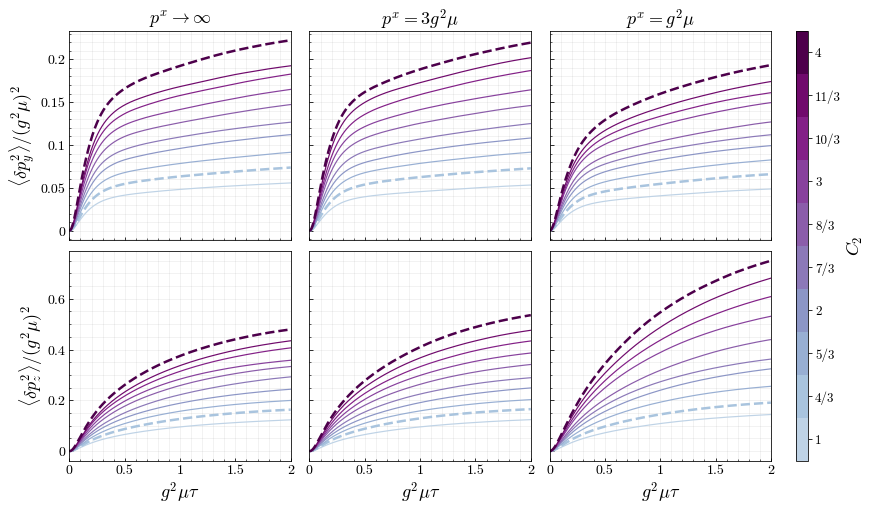

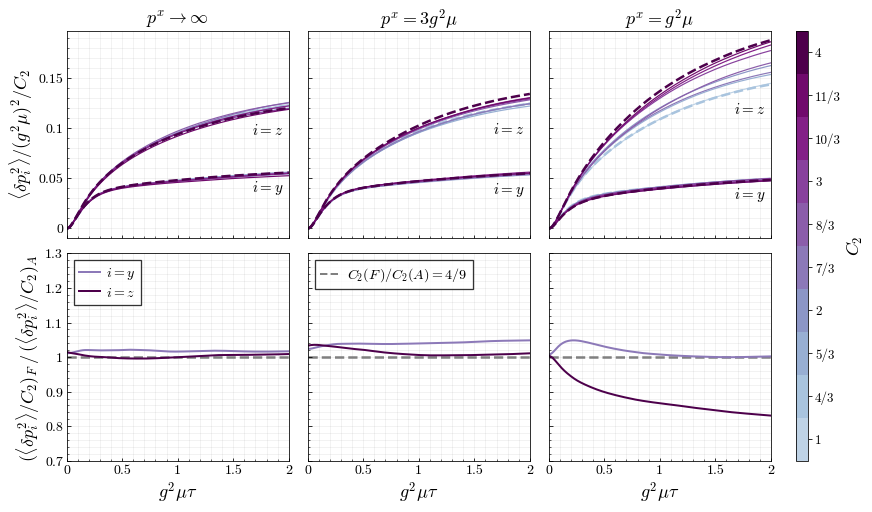

In [14]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from fractions import Fraction

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

# Discrete colormap — skip first 3 bright colors of BuPu
q2s = results["q2s"]
n = len(q2s)
skip = 3
cmap_full = cm.get_cmap('BuPu', n + skip)
colors = [cmap_full(i + skip) for i in range(n)]
cmap  = ListedColormap(colors)
norm  = BoundaryNorm(np.arange(0.5, n + 1.5), cmap.N)

labels_q2 = [str(Fraction(q2).limit_denominator(3)) for q2 in q2s]

ylabel_s   = r'$\langle\delta p^2_i\rangle/(g^2\mu)^2/C_2$'
ylabel_cs  = r'$(\langle\delta p^2_i\rangle/C_2)_F\,/\,(\langle\delta p^2_i\rangle/C_2)_A$'
ylabels    = [r'$\langle\delta p^2_y\rangle/(g^2\mu)^2$',
              r'$\langle\delta p^2_z\rangle/(g^2\mu)^2$']

if mode == 'hq':
    titles = [r'$m\rightarrow\infty$', r'$m=2g^2\mu$', r'$m=g^2\mu$']
elif mode == 'jet':
    titles = [r'$p^x\rightarrow\infty$', r'$p^x=3g^2\mu$', r'$p^x=g^2\mu$']

quarks_cs = results_cs["quarks"]
C2_ratio  = 4 / 9
key_fund  = str(4/3)
key_adj   = str(3.0)
color_y   = colors[4]
color_z   = colors[-1]

def _style(q2):
    highlight = np.isclose(q2, 4/3) or np.isclose(q2, 4.0)
    return (2.5 if highlight else 1.2), ('--' if highlight else '-')

def _safe_ratio(num, den):
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(den != 0, num / den, np.nan)

def _add_legend(ax, handles, loc='upper right', fontsize=14):
    leg = ax.legend(handles=handles, fontsize=fontsize, frameon=True, loc=loc,
                    facecolor='white', edgecolor='black',
                    handlelength=1.5, borderpad=0.4, shadow=False,
                    handletextpad=0.4, labelspacing=0.3)
    leg.get_frame().set_linewidth(1.3)
    leg.get_frame().set_boxstyle('square', pad=0)
    return leg

def _fmt_ax(ax, show_xlabel, show_ylabel, ylabel_str, title=None):
    ax.set_xlim(0, 2.0)
    ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='minor', direction='in')
    if show_xlabel:
        ax.set_xlabel(r'$g^2\mu\tau$', fontsize=18)
    else:
        ax.tick_params(labelbottom=False)
    if show_ylabel:
        ax.set_ylabel(ylabel_str, fontsize=18)
    if title is not None:
        ax.set_title(title, fontsize=18)

def make_fig(scaled=False):
    fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey='row', constrained_layout=True)

    # --- Top row: q2-dep momentum broadening ---
    for iq, quark in enumerate(quarks):
        tau = results["tau"][quark] * g2mu
        tau = tau - tau[0]

        if scaled:
            ax = axes[0, iq]
            for i, q2 in enumerate(q2s):
                lw, ls = _style(q2)
                dp2 = results["psq"][quark][str(q2)] / g2mu**2 / q2
                ax.plot(tau, dp2[:, 1], color=colors[i], linewidth=lw, linestyle=ls)
                ax.plot(tau, dp2[:, 2], color=colors[i], linewidth=lw, linestyle=ls)

            dp2_ref = results["psq"][quark][str(q2s[0])] / g2mu**2 / q2s[0]
            x_label = tau[-1] - 0.05
            ax.annotate(r'$i=y$', xy=(x_label, dp2_ref[-1, 1]),
                        xytext=(0, -6), textcoords='offset points',
                        fontsize=15, color='black', va='top', ha='right')
            ax.annotate(r'$i=z$', xy=(x_label, dp2_ref[-1, 2]),
                        xytext=(0, -18), textcoords='offset points',
                        fontsize=15, color='black', va='top', ha='right')
        else:
            for i, q2 in enumerate(q2s):
                lw, ls = _style(q2)
                dp2 = results["psq"][quark][str(q2)] / g2mu**2
                axes[0, iq].plot(tau, dp2[:, 1], color=colors[i], linewidth=lw, linestyle=ls)
                axes[1, iq].plot(tau, dp2[:, 2], color=colors[i], linewidth=lw, linestyle=ls)

    # --- Bottom row (scaled) or 2nd momentum row (unscaled) ---
    if scaled:
        for iq, quark in enumerate(quarks_cs):
            ax = axes[1, iq]
            tau_cs = results_cs["tau"][quark] * g2mu
            tau_cs = tau_cs - tau_cs[0]

            dp2_fund = results_cs["psq"][quark][key_fund]
            dp2_adj  = results_cs["psq"][quark][key_adj]

            ax.plot(tau_cs, _safe_ratio(dp2_fund[:, 1], dp2_adj[:, 1]) / C2_ratio, color=color_y, linewidth=2)
            ax.plot(tau_cs, _safe_ratio(dp2_fund[:, 2], dp2_adj[:, 2]) / C2_ratio, color=color_z, linewidth=2)
            ax.axhline(1, color='gray', linewidth=2.5, linestyle='--', zorder=0)
            ax.set_ylim(0.7, 1.3)

    # --- Formatting ---
    for iq in range(3):
        if scaled:
            _fmt_ax(axes[0, iq], show_xlabel=False, show_ylabel=(iq==0),
                    ylabel_str=ylabel_s, title=titles[iq])
            _fmt_ax(axes[1, iq], show_xlabel=True,  show_ylabel=(iq==0),
                    ylabel_str=ylabel_cs)
        else:
            _fmt_ax(axes[0, iq], show_xlabel=False, show_ylabel=(iq==0),
                    ylabel_str=ylabels[0], title=titles[iq])
            _fmt_ax(axes[1, iq], show_xlabel=True,  show_ylabel=(iq==0),
                    ylabel_str=ylabels[1])

    # --- Legends (scaled bottom row only) ---
    if scaled:
        _add_legend(axes[1, 0], [
            Line2D([0], [0], color=color_y, linewidth=2, label=r'$i=y$'),
            Line2D([0], [0], color=color_z, linewidth=2, label=r'$i=z$'),
        ], loc='upper left')

        _add_legend(axes[1, 1], [
            Line2D([0], [0], color='gray', linewidth=2, linestyle='--',
                   label=r'$C_2(F\,)/C_2(A)=4/9$'),
        ], loc='upper left')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, aspect=60)
    cbar.set_label(r'$C_2$', fontsize=18)
    cbar.set_ticks(np.arange(1, n + 1))
    cbar.set_ticklabels(labels_q2)
    cbar.ax.tick_params(labelsize=13)

    return fig

fig        = make_fig(scaled=False)
fig_scaled = make_fig(scaled=True)

fig.savefig(f"mom_broad_q2_dep_{mode}.pdf", bbox_inches='tight')
fig.savefig(f"mom_broad_q2_dep_{mode}.png", bbox_inches='tight', dpi=200)
fig_scaled.savefig(f"mom_broad_q2_dep_{mode}_scaled.pdf", bbox_inches='tight')
fig_scaled.savefig(f"mom_broad_q2_dep_{mode}_scaled.png", bbox_inches='tight', dpi=200)
plt.show()

---

In [6]:
q2s = [4/3, 3.0]
nevents = 10

if mode == 'hq':
    quarks = ['infmass', 'beauty', 'charm']
    quark_masses = [10**6, 4.18, 1.27]
    pT = 2
elif mode == 'jet':
    quarks = ['inf', '3g2mu', 'g2mu']
    pxs = [10**6, 3*g2mu, g2mu]

psq, tau = {}, {}
for iq, quark in enumerate(quarks):
    print(quarks[iq].capitalize() + " quark")
    p['QUARK'] = quark
    if mode == 'hq':
        p['MASS'], p['PT'] = quark_masses[iq], pT
        p.pop('PX', None)
        p['TFORM'] = 1/(2*p["MASS"])*hbarc
        if quark == 'infmass':
            p['TFORM'] = 0.
    elif mode == 'jet':
        p['MASS'] = 1
        p['PX'] = pxs[iq]
        p.pop('PT', None)
        p['TFORM'] = 0.

    psq[quark], tau[quark] = {}, {}

    for q2 in q2s:
        p["q2"] = q2
        print("q2 =", p["q2"])

        psqs = []
        for ev in range(nevents):
            output = simulate(p, ev)
            psqs.append(output["psq"])

        psq[quark][str(q2)] = np.mean(psqs, axis=0)

    tau[quark] = output["tau"]

    quark_output = {
        "psq": psq[quark],
        "tau": tau[quark],
        "quark": quark,
        "q2s": q2s,
        "parameters": p.copy(),
    }
    if mode == 'hq':
        quark_output["mass"] = quark_masses[iq]
        filename = f'hq_mom_broad_casimir_scaling_{quark}_N_{N}.pickle'
    elif mode == 'jet':
        quark_output["mass"] = 1
        quark_output["px"] = pxs[iq]
        filename = f'jet_mom_broad_casimir_scaling_{quark}_N_{N}.pickle'
    with open(filename, 'wb') as handle:
        pickle.dump(quark_output, handle)
    print(f"Saved {filename}")

Inf quark
q2 = 1.3333333333333333


Event 10: 100%|██████████| 409/409 [02:56<00:00,  2.32it/s]


q2 = 3.0


Event 10: 100%|██████████| 409/409 [03:00<00:00,  2.27it/s]


Saved jet_mom_broad_casimir_scaling_inf_N_512.pickle
3g2mu quark
q2 = 1.3333333333333333


...

Saved jet_mom_broad_casimir_scaling_3g2mu_N_512.pickle
G2mu quark
q2 = 1.3333333333333333


Event 10: 100%|██████████| 409/409 [02:56<00:00,  2.31it/s]


q2 = 3.0


Event 10: 100%|██████████| 409/409 [03:26<00:00,  1.98it/s]

Saved jet_mom_broad_casimir_scaling_g2mu_N_512.pickle
